# TP2 -- Clasificacion Supervisada: Modelos

**Materia:** 72.75 Aprendizaje Automatico (Machine Learning) -- ITBA

Importa los datos limpios de `01_limpieza.ipynb` (`data/processed/train.csv` y `data/processed/test.csv`).
Entrena 5 clasificadores con k-fold CV estratificado, ajusta hiperparametros con curvas de validacion,
compara modelos y evalua el mejor en el test set.

**Para cambiar que modelos correr:** modificar `MODELS_TO_RUN` en la celda CONFIG.

## CONFIG -- modificar aqui

In [13]:
# ============================================================
# CONFIG
# ============================================================
MODELS_TO_RUN = ["naive_bayes", "lda", "svm", "knn", "rf"]  # subset o todos

METRICS       = ["recall", "roc_auc"]   # recall: minimizar FN clinicos; roc_auc: ranking threshold-free
CV_FOLDS      = 5
RANDOM_STATE  = 42
OUTPUT_DIR    = "outputs"

TRAIN_PATH    = "data/processed/train.csv"
TEST_PATH     = "data/processed/test.csv"
print("ok!")

ok!


## Imports

In [14]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.naive_bayes     import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import RandomForestClassifier

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     validation_curve, GridSearchCV)
from sklearn.metrics         import (
    recall_score, roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

print("Imports OK")

Imports OK


## Registro de modelos e hiperparametros

In [15]:
MODEL_REGISTRY = {
    "naive_bayes": GaussianNB(),
    "lda":         LinearDiscriminantAnalysis(),
    "svm":         SVC(probability=True, random_state=RANDOM_STATE),
    "knn":         KNeighborsClassifier(),
    "rf":          RandomForestClassifier(random_state=RANDOM_STATE),
}

MODEL_LABELS = {
    "naive_bayes": "Naive Bayes",
    "lda":         "LDA",
    "svm":         "SVM",
    "knn":         "KNN",
    "rf":          "Random Forest",
}

METRIC_LABELS = {
    "recall":   "Recall (Sensibilidad)  TP / (TP + FN)",
    "roc_auc":  "ROC-AUC  — Área bajo la curva ROC",
    "f1":       "F1-Score  — Media armónica precisión/recall",
    "accuracy": "Accuracy  — Fracción de predicciones correctas",
}

# Curvas de validación 1D (un parámetro a la vez)
VALIDATION_CURVES = {
    "svm": [
        ("classifier__C",      np.logspace(-3, 3, 10), "C (regularización)",        True),
    ],
    "knn": [
        ("classifier__n_neighbors", np.arange(1, 31), "k (número de vecinos)",      False),
    ],
    "rf":  [
        ("classifier__max_depth",   np.arange(1, 16), "Profundidad máxima del árbol", False),
    ],
    "naive_bayes": [
        ("classifier__var_smoothing", np.logspace(-12, -1, 15), "Var smoothing", True),
    ],
    "lda": [
        ("classifier__shrinkage", np.linspace(0, 1, 20), "Shrinkage (regularización)", False),
    ],
}

# Grid 2D para modelos con múltiples hiperparámetros
PARAM_GRIDS_2D = {
    "svm": {
        "grid":   {"classifier__C":      np.logspace(-2, 3, 7),
                   "classifier__kernel": ["linear", "rbf", "poly"]},
        "param1": "classifier__C",
        "param2": "classifier__kernel",
        "label1": "C (regularización)",
        "label2": "Kernel",
    },
    "knn": {
        "grid":   {"classifier__n_neighbors": list(range(1, 22, 2)),
                   "classifier__weights":     ["uniform", "distance"]},
        "param1": "classifier__n_neighbors",
        "param2": "classifier__weights",
        "label1": "k (número de vecinos)",
        "label2": "Ponderación de vecinos",
    },
    "rf":  {
        "grid":   {"classifier__max_depth":    [2, 4, 6, 8, 10, 15, None],
                   "classifier__n_estimators": [50, 100, 200, 300]},
        "param1": "classifier__max_depth",
        "param2": "classifier__n_estimators",
        "label1": "Profundidad máxima del árbol",
        "label2": "Número de árboles",
    },
}

# Mejores hiperparámetros — actualizar con los valores del heatmap
BEST_PARAMS = {
    "naive_bayes": {"classifier__var_smoothing": 1e-5},
    "lda":         {"classifier__solver": "lsqr", "classifier__shrinkage": 0.1},
    "svm": {"classifier__C": 1.0,  "classifier__kernel": "rbf"},
    "knn": {"classifier__n_neighbors": 7},
    "rf":  {"classifier__n_estimators": 200, "classifier__max_depth": None},
}

print(f"Modelos registrados: {list(MODEL_REGISTRY.keys())}")
print(f"Modelos a correr:    {MODELS_TO_RUN}")

Modelos registrados: ['naive_bayes', 'lda', 'svm', 'knn', 'rf']
Modelos a correr:    ['naive_bayes', 'lda', 'svm', 'knn', 'rf']


## Carga de datos

In [16]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

X_train = train_df.drop(columns=["diagnosis"])
y_train = train_df["diagnosis"]
X_test  = test_df.drop(columns=["diagnosis"])
y_test  = test_df["diagnosis"]

FEATURES = list(X_train.columns)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"\nBalance train -- B: {(y_train==0).sum()} ({100*(y_train==0).mean():.1f}%)  "
      f"M: {(y_train==1).sum()} ({100*(y_train==1).mean():.1f}%)")

Train: (455, 17)  |  Test: (114, 17)
Features (17): ['perimeter_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Balance train -- B: 285 (62.6%)  M: 170 (37.4%)


## Funciones auxiliares (agnosticas al modelo)

In [17]:
def make_pipeline(model):
    """Scaler dentro del pipeline para evitar data leakage en CV."""
    return Pipeline([("scaler", StandardScaler()), ("classifier", model)])


def run_cv(model_name, model, X, y, cv):
    pipe = make_pipeline(model)
    scoring = {"recall": "recall", "roc_auc": "roc_auc",
               "f1": "f1", "accuracy": "accuracy"}
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring,
                             return_train_score=True, n_jobs=-1)
    summary = {}
    for metric in scoring:
        summary[f"{metric}_mean"] = results[f"test_{metric}"].mean()
        summary[f"{metric}_std"]  = results[f"test_{metric}"].std()
    print(f"  [{model_name:12s}]  recall={summary['recall_mean']:.3f}±{summary['recall_std']:.3f}  "
          f"roc_auc={summary['roc_auc_mean']:.3f}±{summary['roc_auc_std']:.3f}")
    return summary


def plot_validation_curve(pipe, param_name, param_range, X, y, cv,
                          scoring="recall", x_label=None, log_scale=False, save_path=None):
    train_scores, val_scores = validation_curve(
        pipe, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    metric_title = METRIC_LABELS.get(scoring, scoring)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(param_range, train_scores.mean(axis=1), "o-", color="#2980B9", label="Train")
    ax.fill_between(param_range,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color="#2980B9")
    ax.plot(param_range, val_scores.mean(axis=1), "o-", color="#C0392B", label="Validación (CV)")
    ax.fill_between(param_range,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color="#C0392B")
    ax.set_xlabel(x_label or param_name, fontsize=11)
    ax.set_ylabel(metric_title, fontsize=10)
    ax.set_title(f"Curva de validación — {x_label or param_name}\n({metric_title})",
                 fontsize=11, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if log_scale:
        ax.set_xscale("log")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_hyperparam_heatmap(model_name, model, cfg, X, y, cv,
                             scoring="recall", save_path=None):
    """GridSearchCV 2D → heatmap con la mejor combinación marcada."""
    pipe = make_pipeline(model)
    gs = GridSearchCV(pipe, cfg["grid"], cv=cv, scoring=scoring,
                      n_jobs=-1, refit=False)
    gs.fit(X, y)

    res = pd.DataFrame(gs.cv_results_)
    p1_col = f"param_{cfg['param1']}"
    p2_col = f"param_{cfg['param2']}"

    # Formatear None → "None" y floats → 4 decimales para que pivot funcione
    def _fmt(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return "None"
        if isinstance(v, (int, np.integer)):
            return str(v)
        try:
            return f"{float(v):.4f}"
        except (ValueError, TypeError):
            return str(v)
    res[p1_col] = res[p1_col].apply(_fmt)
    res[p2_col] = res[p2_col].apply(_fmt)

    pivot = res.pivot_table(index=p1_col, columns=p2_col,
                            values="mean_test_score")
    std_pivot = res.pivot_table(index=p1_col, columns=p2_col,
                                values="std_test_score")

    # Ordenar eje Y (param1) de mayor a menor valor numérico
    def _idx_sort_key(v):
        if v == "None":
            return float("inf")
        try:
            return float(v)
        except (ValueError, TypeError):
            return v

    sorted_idx = sorted(pivot.index, key=_idx_sort_key, reverse=True)
    pivot     = pivot.loc[sorted_idx]
    std_pivot = std_pivot.loc[sorted_idx]

    best_idx   = res["mean_test_score"].idxmax()
    best_p1    = res.loc[best_idx, p1_col]
    best_p2    = res.loc[best_idx, p2_col]
    best_score = res.loc[best_idx, "mean_test_score"]
    best_std   = res.loc[best_idx, "std_test_score"]

    # Anotaciones: mean ± std
    annot = pivot.copy().astype(str)
    for r in pivot.index:
        for c in pivot.columns:
            annot.loc[r, c] = f"{pivot.loc[r, c]:.3f}\n±{std_pivot.loc[r, c]:.3f}"

    fig_w = max(7, len(pivot.columns) * 1.6)
    fig_h = max(4, len(pivot.index) * 0.9)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    sns.heatmap(pivot.astype(float), annot=annot, fmt="", cmap="RdYlGn",
                vmin=pivot.values.min() - 0.02, vmax=min(1.0, pivot.values.max() + 0.02),
                ax=ax, linewidths=0.5,
                cbar_kws={"label": METRIC_LABELS.get(scoring, scoring), "shrink": 0.8})

    # Marcar la mejor celda con borde negro
    best_col_idx = list(pivot.columns).index(best_p2)
    best_row_idx = list(pivot.index).index(best_p1)
    ax.add_patch(plt.Rectangle((best_col_idx, best_row_idx), 1, 1,
                                fill=False, edgecolor="black", lw=3))

    ax.set_xlabel(cfg["label2"], fontsize=11)
    ax.set_ylabel(cfg["label1"], fontsize=11)
    ax.set_title(
        f"Grid de hiperparámetros — {MODEL_LABELS[model_name]}\n"
        f"{METRIC_LABELS.get(scoring, scoring)}  (CV {cv.n_splits}-fold)  |  "
        f"Mejor: {cfg['label1']}={best_p1},  {cfg['label2']}={best_p2}  →  {best_score:.3f} ± {best_std:.3f}",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"  Mejor: {cfg['param1']}={best_p1},  {cfg['param2']}={best_p2}  "
          f"→  {scoring}={best_score:.4f} ± {best_std:.4f}")
    return best_p1, best_p2


def plot_confusion_matrix(model, X_test, y_test, model_label, save_path=None):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno (0)", "Maligno (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Matriz de confusión — {model_label}\n"
                 f"(filas: real, columnas: predicho)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_roc_curve(model, X_test, y_test, model_label, ax=None, save_path=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_label)
    if standalone:
        ax.set_title(f"Curva ROC — {model_label}\n"
                     f"(TPR vs FPR para todos los umbrales)", fontsize=11, fontweight="bold")
        ax.set_xlabel("Tasa de Falsos Positivos  (FP / (FP + TN))")
        ax.set_ylabel("Tasa de Verdaderos Positivos  (TP / (TP + FN))")
        ax.grid(linestyle="--", alpha=0.4)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, bbox_inches="tight")
        plt.show()
        plt.close(fig)


def ensure_output_dir(model_name):
    path = os.path.join(OUTPUT_DIR, model_name)
    os.makedirs(path, exist_ok=True)
    return path


print("Helpers definidos.")

Helpers definidos.


## CV baseline -- todos los modelos con defaults

In [18]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
print(f"CV baseline ({CV_FOLDS}-fold estratificado):")
for name in MODELS_TO_RUN:
    cv_results[name] = run_cv(name, MODEL_REGISTRY[name], X_train, y_train, cv)

CV baseline (5-fold estratificado):


  [naive_bayes ]  recall=0.906±0.034  roc_auc=0.985±0.007
  [lda         ]  recall=0.876±0.057  roc_auc=0.989±0.008
  [svm         ]  recall=0.959±0.030  roc_auc=0.995±0.005
  [knn         ]  recall=0.918±0.022  roc_auc=0.980±0.010
  [rf          ]  recall=0.924±0.055  roc_auc=0.989±0.007


### Comparacion CV baseline

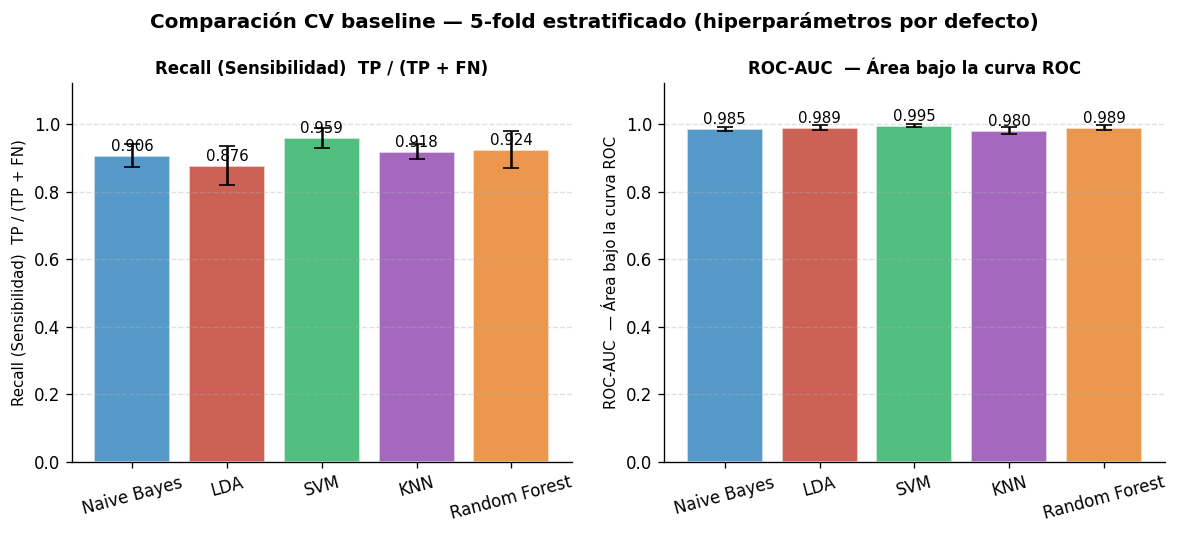

In [19]:
metrics_to_plot = ["recall", "roc_auc"]
model_names = list(cv_results.keys())
labels = [MODEL_LABELS[m] for m in model_names]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 4.5))
if len(metrics_to_plot) == 1:
    axes = [axes]

colors = ["#2980B9", "#C0392B", "#27AE60", "#8E44AD", "#E67E22"]

for ax, metric in zip(axes, metrics_to_plot):
    means = [cv_results[m][f"{metric}_mean"] for m in model_names]
    stds  = [cv_results[m][f"{metric}_std"]  for m in model_names]
    bars = ax.bar(labels, means, yerr=stds, capsize=5,
                  color=colors[:len(model_names)], alpha=0.8, edgecolor="white")
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight="bold")
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(f"Comparación CV baseline — {CV_FOLDS}-fold estratificado (hiperparámetros por defecto)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "cv_baseline_comparison.png"), bbox_inches="tight")
plt.show()
plt.close(fig)

## Ajuste de hiperparametros -- curvas de validacion

Se generan curvas de validacion para SVM (C), KNN (k) y RF (max_depth).
Cada curva muestra train vs CV para detectar overfitting/underfitting.


--- Curvas de validacion: SVM ---


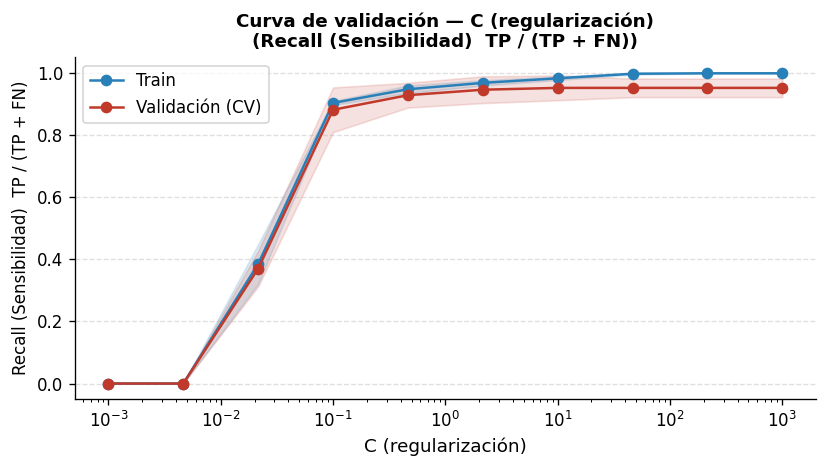


--- Curvas de validacion: KNN ---


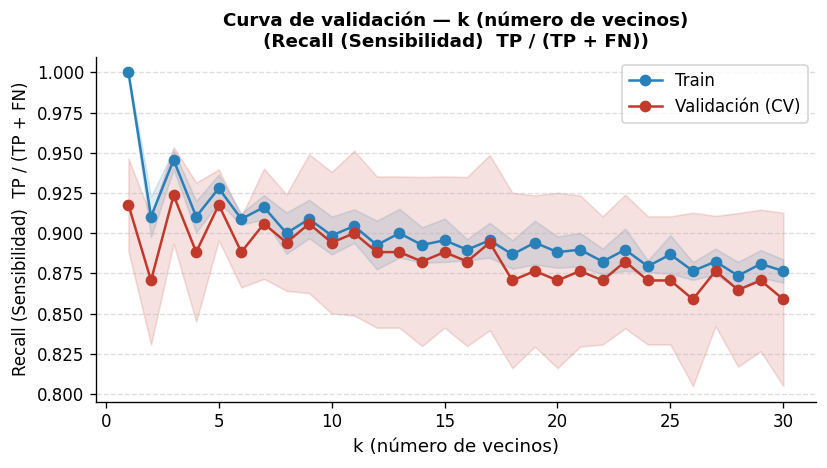


--- Curvas de validacion: Random Forest ---


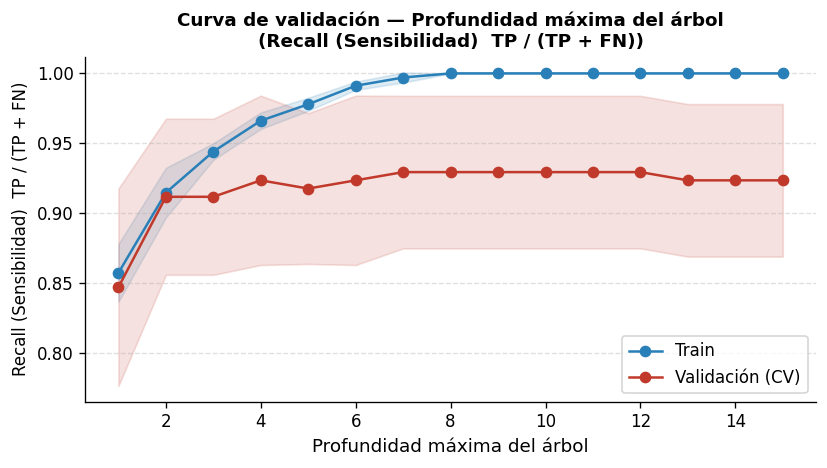


--- Curvas de validacion: Naive Bayes ---


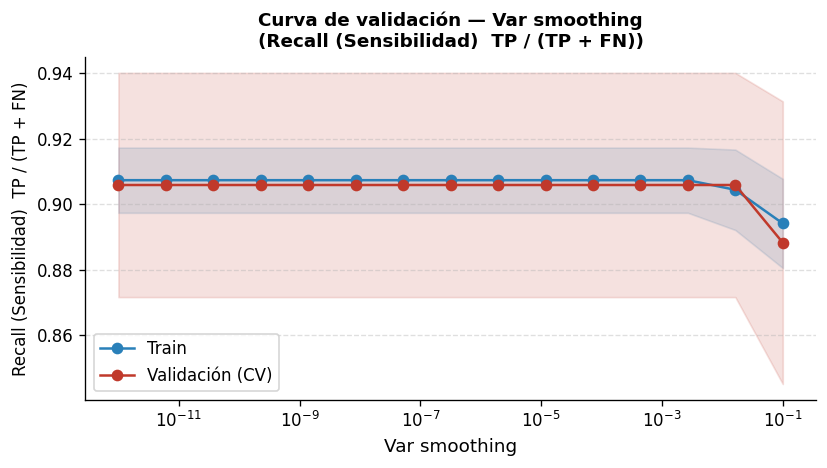


--- Curvas de validacion: LDA ---


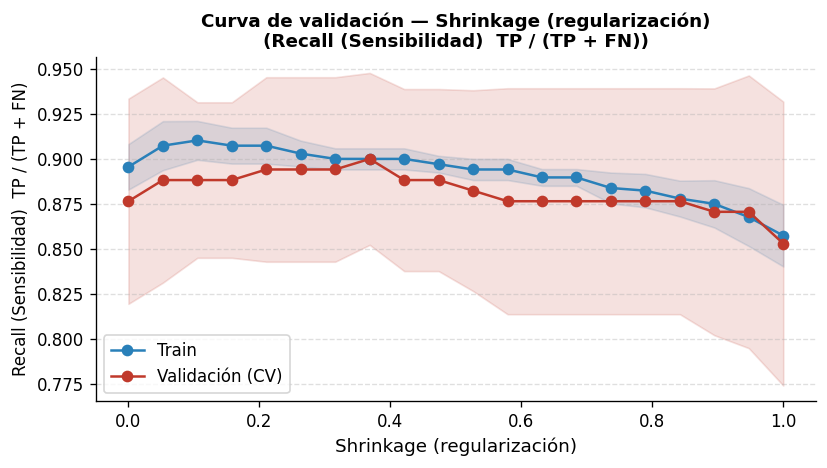

In [20]:
from sklearn.base import clone
for model_name, curves in VALIDATION_CURVES.items():
    if model_name not in MODELS_TO_RUN:
        continue
    out_dir = ensure_output_dir(model_name)
    model = clone(MODEL_REGISTRY[model_name])
    if model_name == "lda":
        model.set_params(solver="lsqr")
    pipe = make_pipeline(model)
    print(f"\n--- Curvas de validacion: {MODEL_LABELS[model_name]} ---")
    for param_name, param_range, x_label, log_scale in curves:
        save_path = os.path.join(out_dir, f"val_curve_{x_label.replace('/', '_')}.png")
        plot_validation_curve(pipe, param_name, param_range, X_train, y_train, cv,
                              scoring="recall", x_label=x_label,
                              log_scale=log_scale, save_path=save_path)

### Búsqueda en grid 2D — combinación de hiperparámetros

Para cada modelo con múltiples hiperparámetros se corre un `GridSearchCV` exhaustivo
y se visualiza el resultado como heatmap. Cada celda muestra `mean ± std` del CV.
La mejor combinación queda enmarcada en negro.

Después de ver estos heatmaps, actualizar `BEST_PARAMS` en la celda de registro.

Grid 2D de hiperparámetros (GridSearchCV):

--- SVM ---


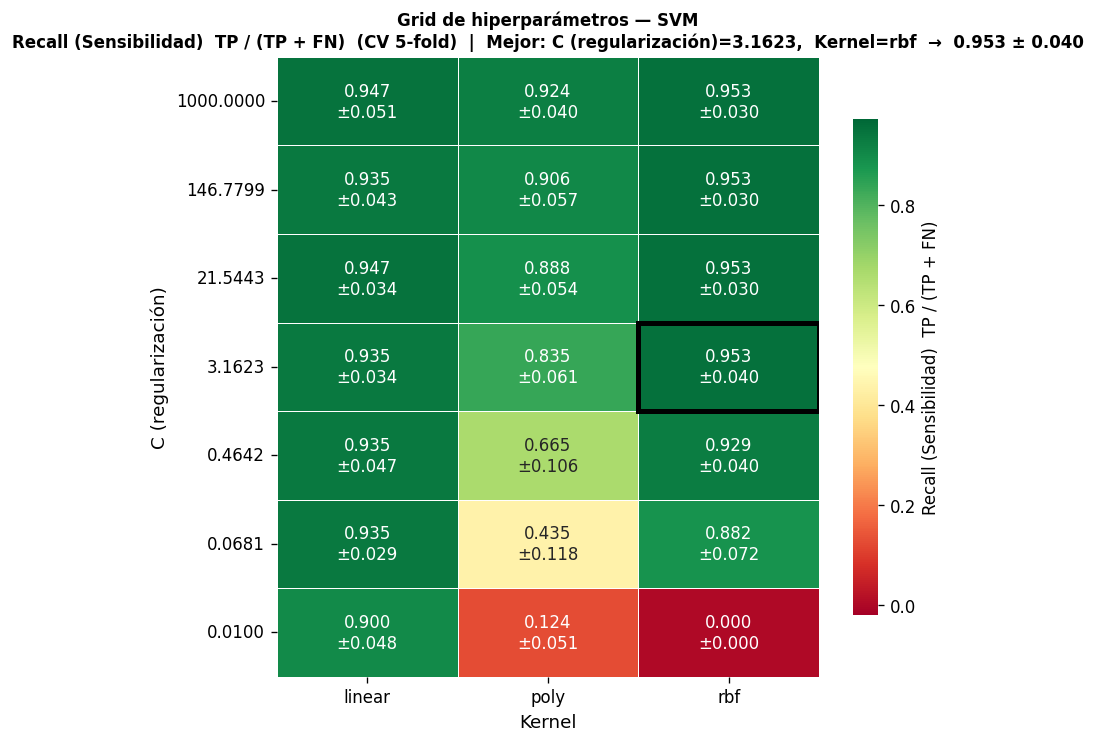

  Mejor: classifier__C=3.1623,  classifier__kernel=rbf  →  recall=0.9529 ± 0.0399

--- KNN ---


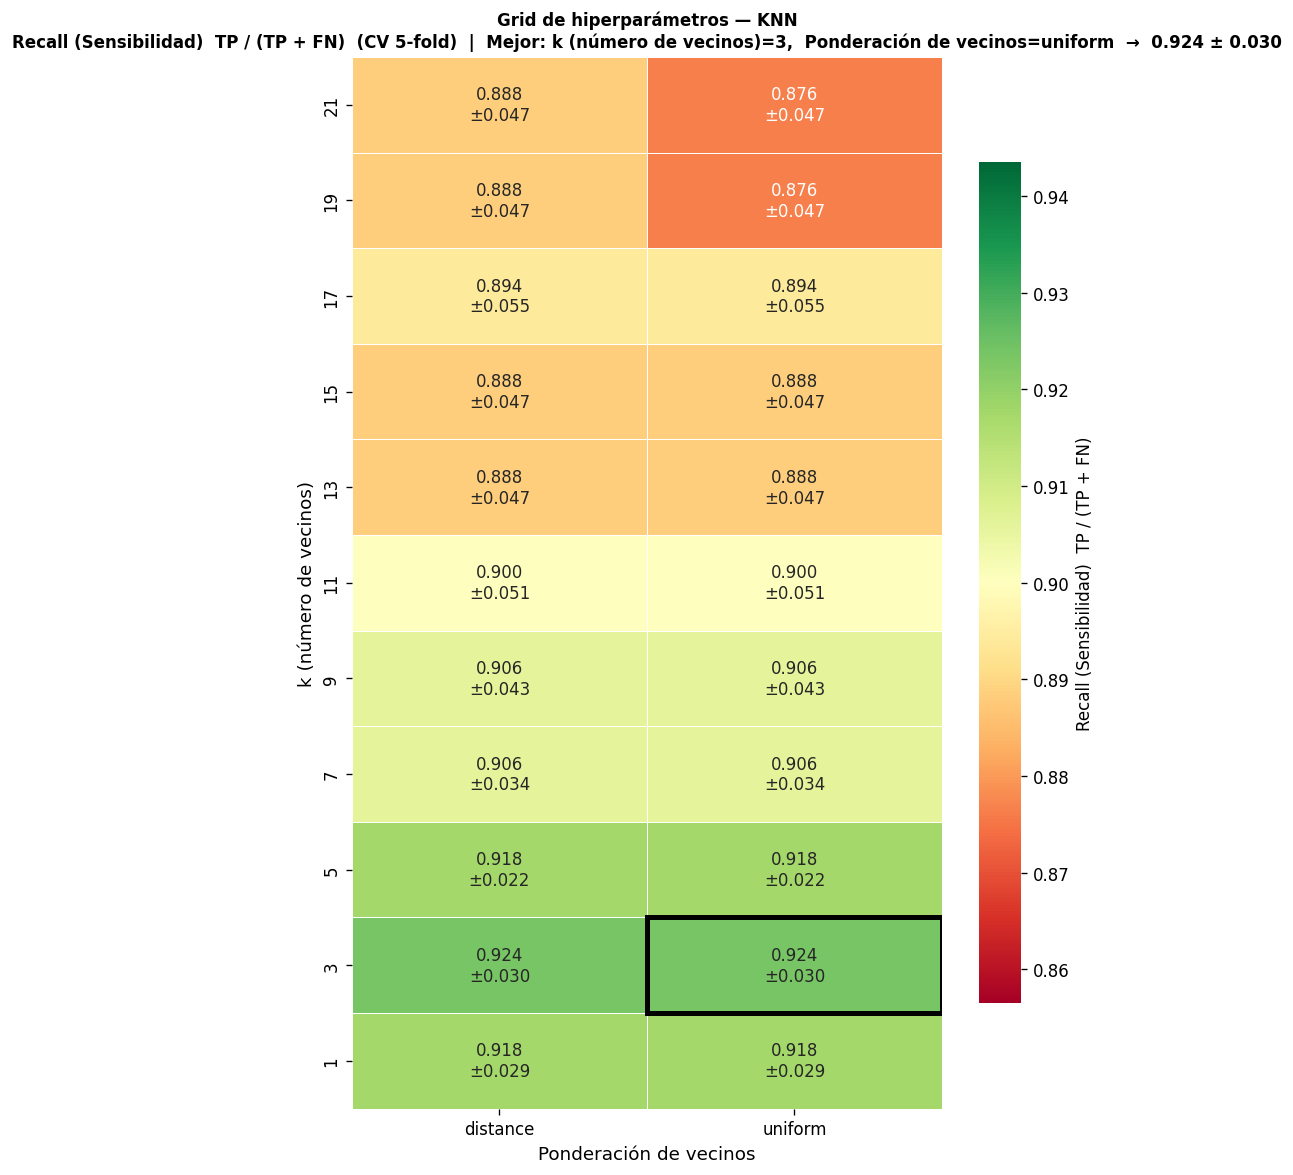

  Mejor: classifier__n_neighbors=3,  classifier__weights=uniform  →  recall=0.9235 ± 0.0300

--- Random Forest ---


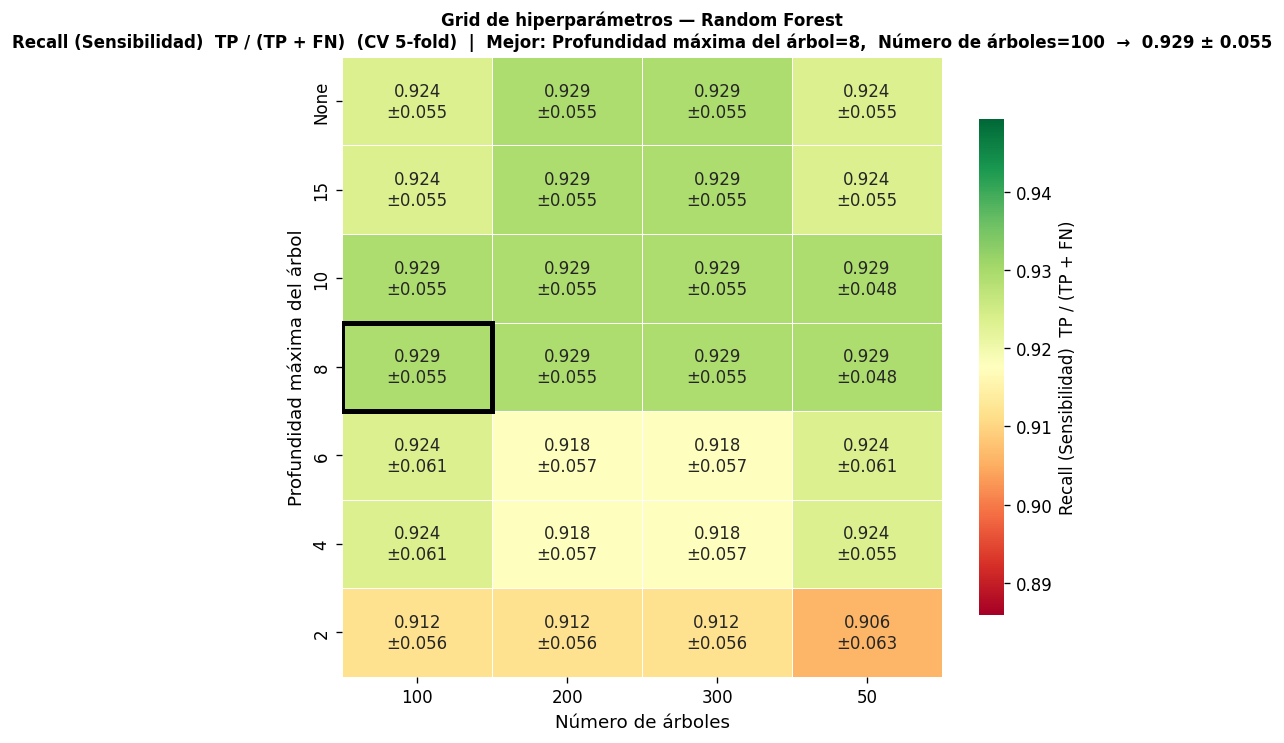

  Mejor: classifier__max_depth=8,  classifier__n_estimators=100  →  recall=0.9294 ± 0.0546


In [21]:
print("Grid 2D de hiperparámetros (GridSearchCV):")
for model_name, cfg in PARAM_GRIDS_2D.items():
    if model_name not in MODELS_TO_RUN:
        continue
    out_dir = ensure_output_dir(model_name)
    print(f"\n--- {MODEL_LABELS[model_name]} ---")
    plot_hyperparam_heatmap(
        model_name, MODEL_REGISTRY[model_name], cfg,
        X_train, y_train, cv,
        scoring="recall",
        save_path=os.path.join(out_dir, "hyperparam_grid.png")
    )

## CV con mejores hiperparametros

Actualizar `BEST_PARAMS` en la celda de registro con los valores elegidos de las curvas.

In [22]:
cv_results_tuned = {}

print(f"CV tuned ({CV_FOLDS}-fold estratificado):")
for name in MODELS_TO_RUN:
    model = MODEL_REGISTRY[name]
    if name == "lda":
        model.set_params(solver="lsqr")
    pipe  = make_pipeline(model)
    if name in BEST_PARAMS:
        pipe.set_params(**BEST_PARAMS[name])
    scoring = {"recall": "recall", "roc_auc": "roc_auc",
               "f1": "f1", "accuracy": "accuracy"}
    results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                             return_train_score=True, n_jobs=-1)
    summary = {}
    for metric in scoring:
        summary[f"{metric}_mean"] = results[f"test_{metric}"].mean()
        summary[f"{metric}_std"]  = results[f"test_{metric}"].std()
    cv_results_tuned[name] = summary
    print(f"  [{name:12s}]  recall={summary['recall_mean']:.3f}±{summary['recall_std']:.3f}  "
          f"roc_auc={summary['roc_auc_mean']:.3f}±{summary['roc_auc_std']:.3f}")

CV tuned (5-fold estratificado):
  [naive_bayes ]  recall=0.906±0.034  roc_auc=0.985±0.007
  [lda         ]  recall=0.882±0.049  roc_auc=0.991±0.008
  [svm         ]  recall=0.959±0.030  roc_auc=0.995±0.005
  [knn         ]  recall=0.906±0.034  roc_auc=0.983±0.012
  [rf          ]  recall=0.929±0.055  roc_auc=0.990±0.007


## Analisis de overfitting / underfitting

### Caracteristicas de cada modelo y su tendencia al overfitting/underfitting

| Modelo | Tipo | Tendencia | Detalle |
|---|---|---|---|
| **Naive Bayes** | Generativo, parametrico | **Underfitting** (alto sesgo) | Asume independencia condicional entre features, lo cual se viola en este dataset (hay pares con \|r\|>0.70). Esto limita su capacidad de capturar interacciones, generando un sesgo alto. No tiene hiperparametros para tunear. |
| **LDA** | Discriminativo, parametrico | **Underfitting** (alto sesgo) | Asume distribucion Gaussiana por clase con matrices de covarianza compartidas. La frontera de decision es lineal. Si la frontera real es no-lineal, LDA no puede capturarla y subajusta. |
| **SVM (RBF)** | Discriminativo, no parametrico | **Overfitting** si C es alto | Con kernel RBF puede aprender fronteras muy complejas. C alto → menos regularizacion → memoriza ruido. El kernel `linear` es mas conservador. La eleccion de C y kernel es critica. |
| **KNN** | Basado en instancias, no parametrico | Depende de **k** | k chico (1-3) → frontera muy irregular → overfitting. k grande → frontera suave → underfitting. Con 17 features la distancia Euclidea pierde significado (maldicion de dimensionalidad), pero StandardScaler mitiga el efecto. |
| **Random Forest** | Ensemble (bagging) | **Overfitting** si `max_depth` es alta | Cada arbol puede crecer hasta memorizar los datos. El promediado de muchos arboles reduce la varianza, pero si todos overfittean, el ensemble tambien. `max_depth` limita la complejidad de cada arbol. |

### Diagnostico esperado

- **NB y LDA:** recall CV moderado (~0.88), gap train-CV chico → subajuste por limitaciones del modelo.
- **SVM (RBF):** recall CV alto (~0.96), gap depende de C. Con C bien elegido deberia estar equilibrado.
- **KNN:** recall CV variable segun k. k chico → gap grande (overfitting), k grande → recall bajo (underfitting).
- **RF:** recall CV alto pero gap train-CV puede ser amplio si `max_depth` no se controla (arboles memorizan train).

Configuracion usada por cada modelo

  Naive Bayes (naive_bayes)
    Defaults sklearn : {'var_smoothing': 1e-09}
    Params aplicados : {'classifier__var_smoothing': 1e-05}

  LDA (lda)
    Defaults sklearn : {'solver': 'svd', 'shrinkage': None, 'tol': 0.0001}
    Params aplicados : {'classifier__solver': 'lsqr', 'classifier__shrinkage': 0.1}

  SVM (svm)
    Defaults sklearn : {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'probability': True}
    Params aplicados : {'classifier__C': 1.0, 'classifier__kernel': 'rbf'}

  KNN (knn)
    Defaults sklearn : {'n_neighbors': 5, 'weights': 'uniform'}
    Params aplicados : {'classifier__n_neighbors': 7}

  Random Forest (rf)
    Defaults sklearn : {'n_estimators': 100, 'max_depth': None, 'random_state': 42}
    Params aplicados : {'classifier__n_estimators': 200, 'classifier__max_depth': None}

Tabla diagnostica: Train vs CV (modelos tuneados)

Modelo          | Recall Train    Recall CV      Gap |  AUC Train     AUC CV      Gap | Diagnostico


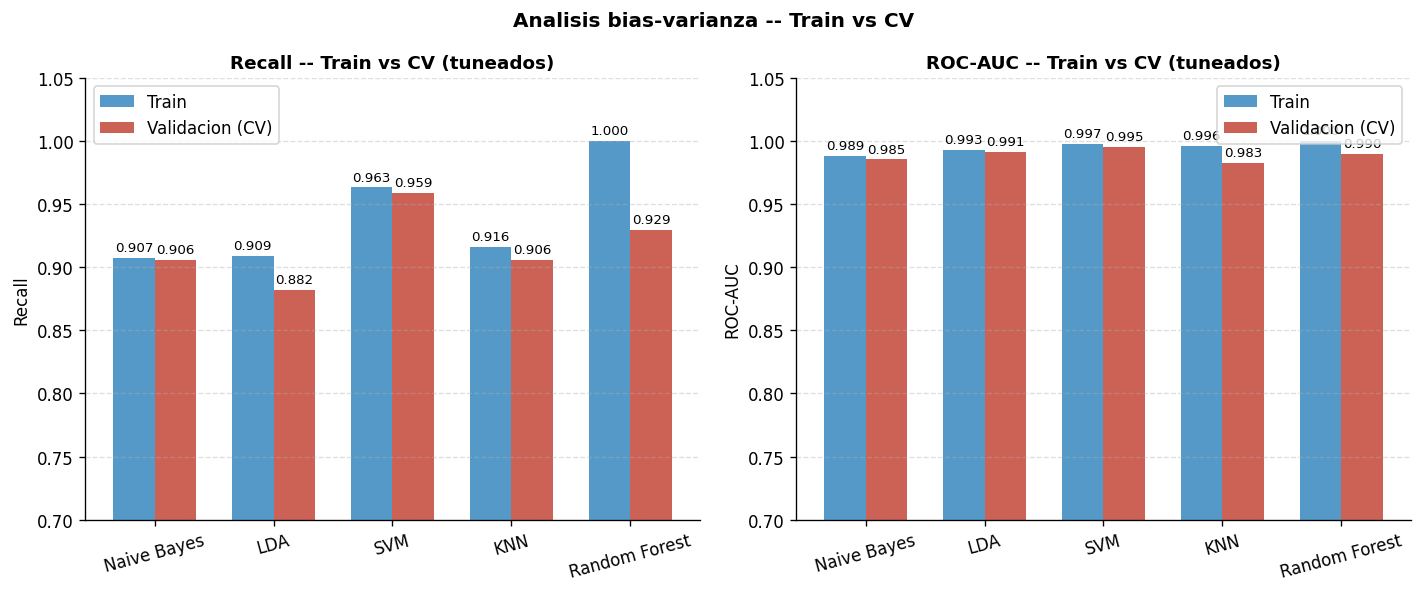

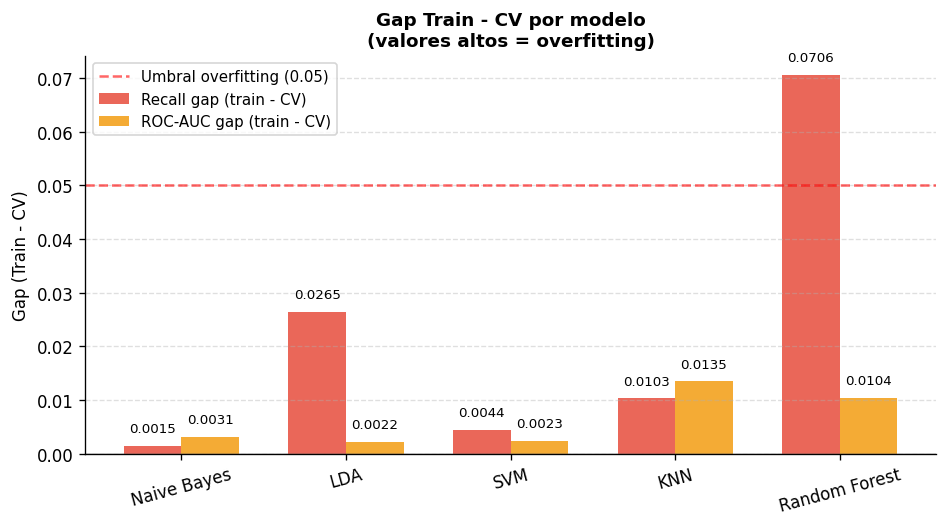

In [23]:
from sklearn.base import clone

GAP_THRESHOLD = 0.05

DEFAULT_PARAMS = {
    "naive_bayes": {"var_smoothing": 1e-9},
    "lda":         {"solver": "svd", "shrinkage": None, "tol": 1e-4},
    "svm":         {"C": 1.0, "kernel": "rbf", "gamma": "scale", "probability": True},
    "knn":         {"n_neighbors": 5, "weights": "uniform"},
    "rf":          {"n_estimators": 100, "max_depth": None, "random_state": 42},
}

print("=" * 75)
print("Configuracion usada por cada modelo")
print("=" * 75)
for name in MODELS_TO_RUN:
    label = MODEL_LABELS[name]
    defs = DEFAULT_PARAMS.get(name, {})
    tuned = BEST_PARAMS.get(name, None)
    print(f"\n  {label} ({name})")
    print(f"    Defaults sklearn : {defs}")
    if tuned:
        print(f"    Params aplicados : {tuned}")
    else:
        print(f"    Params aplicados : (defaults -- sin tuning)")

overfit_data = {}
for name in MODELS_TO_RUN:
    model = clone(MODEL_REGISTRY[name])
    if name == "lda":
        model.set_params(solver="lsqr")
    pipe = make_pipeline(model)
    if name in BEST_PARAMS:
        pipe.set_params(**BEST_PARAMS[name])
    scoring = {"recall": "recall", "roc_auc": "roc_auc"}
    results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                             return_train_score=True, n_jobs=-1)
    overfit_data[name] = {
        "recall_train":  results["train_recall"].mean(),
        "recall_cv":     results["test_recall"].mean(),
        "roc_auc_train": results["train_roc_auc"].mean(),
        "roc_auc_cv":    results["test_roc_auc"].mean(),
    }

print("\n" + "=" * 75)
print("Tabla diagnostica: Train vs CV (modelos tuneados)")
print("=" * 75)
print(f"\n{'Modelo':15s} | {'Recall Train':>12s} {'Recall CV':>12s} {'Gap':>8s} | "
      f"{'AUC Train':>10s} {'AUC CV':>10s} {'Gap':>8s} | Diagnostico")
print("-" * 105)

for name in MODELS_TO_RUN:
    d = overfit_data[name]
    recall_gap = d["recall_train"] - d["recall_cv"]
    auc_gap    = d["roc_auc_train"] - d["roc_auc_cv"]
    if recall_gap > GAP_THRESHOLD or auc_gap > GAP_THRESHOLD:
        diag = "OVERFITTING"
    elif d["recall_cv"] < 0.85 and d["recall_train"] < 0.90:
        diag = "UNDERFITTING"
    else:
        diag = "OK"
    print(f"{MODEL_LABELS[name]:15s} | {d['recall_train']:12.4f} {d['recall_cv']:12.4f} {recall_gap:8.4f} | "
          f"{d['roc_auc_train']:10.4f} {d['roc_auc_cv']:10.4f} {auc_gap:8.4f} | {diag}")

# --- Grafico 1: Train vs CV agrupado ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metrics_display = [("recall", "Recall"), ("roc_auc", "ROC-AUC")]
x = np.arange(len(MODELS_TO_RUN))
width = 0.35

for ax, (metric, label) in zip(axes, metrics_display):
    train_vals = [overfit_data[n][f"{metric}_train"] for n in MODELS_TO_RUN]
    cv_vals    = [overfit_data[n][f"{metric}_cv"] for n in MODELS_TO_RUN]
    labels     = [MODEL_LABELS[n] for n in MODELS_TO_RUN]

    bars1 = ax.bar(x - width/2, train_vals, width, label="Train", color="#2980B9", alpha=0.8)
    bars2 = ax.bar(x + width/2, cv_vals, width, label="Validacion (CV)", color="#C0392B", alpha=0.8)

    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} -- Train vs CV (tuneados)", fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.legend()
    ax.set_ylim(0.7, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bar, val in zip(bars1, train_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    for bar, val in zip(bars2, cv_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Analisis bias-varianza -- Train vs CV", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "overfitting_train_vs_cv.png"), bbox_inches="tight")
plt.show()
plt.close(fig)

# --- Grafico 2: Gaps ---
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [MODEL_LABELS[n] for n in MODELS_TO_RUN]
recall_gaps = [overfit_data[n]["recall_train"] - overfit_data[n]["recall_cv"] for n in MODELS_TO_RUN]
auc_gaps    = [overfit_data[n]["roc_auc_train"] - overfit_data[n]["roc_auc_cv"] for n in MODELS_TO_RUN]

x = np.arange(len(MODELS_TO_RUN))
width = 0.35
bars1 = ax.bar(x - width/2, recall_gaps, width, label="Recall gap (train - CV)", color="#E74C3C", alpha=0.85)
bars2 = ax.bar(x + width/2, auc_gaps, width, label="ROC-AUC gap (train - CV)", color="#F39C12", alpha=0.85)

ax.axhline(y=GAP_THRESHOLD, color="red", linestyle="--", alpha=0.6, label=f"Umbral overfitting ({GAP_THRESHOLD})")
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.3)

for bar, val in zip(bars1, recall_gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, auc_gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Gap (Train - CV)")
ax.set_title("Gap Train - CV por modelo\n(valores altos = overfitting)", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "overfitting_gaps.png"), bbox_inches="tight")
plt.show()
plt.close(fig)

### Conclusiones del analisis

Escribir conclusiones despues de ejecutar la celda anterior.

- **Modelos con overfitting:** el gap train-CV es grande → el modelo memoriza el train pero no generaliza. Solucion: mas regularizacion (C mas chico en SVM, max_depth mas baja en RF, k mas grande en KNN).
- **Modelos con underfitting:** tanto train como CV son bajos → el modelo es demasiado simple. Solucion: mas capacidad (kernel RBF en SVM, k mas chico en KNN, mas arboles/profundidad en RF).
- **Modelos equilibrados:** gap pequeno y CV alto → buen tradeoff sesgo-varianza.

### Before vs After: impacto del tuning

Compara el rendimiento CV con defaults vs hiperparametros tuneados.
Solo se muestran los modelos donde el tuning tiene efecto (NB, LDA, SVM, KNN, RF).


Modelo          | Recall Default  Recall Tuned    Delta |  AUC Default  AUC Tuned    Delta
-----------------------------------------------------------------------------------------------
Naive Bayes     |         0.9059        0.9059  +0.0000 |       0.9854     0.9854  +0.0000
LDA             |         0.8765        0.8824  +0.0059 |       0.9892     0.9911  +0.0020
SVM             |         0.9588        0.9588  +0.0000 |       0.9951     0.9951  +0.0000
KNN             |         0.9059        0.9059  +0.0000 |       0.9830     0.9830  +0.0000
Random Forest   |         0.9294        0.9294  +0.0000 |       0.9896     0.9896  +0.0000


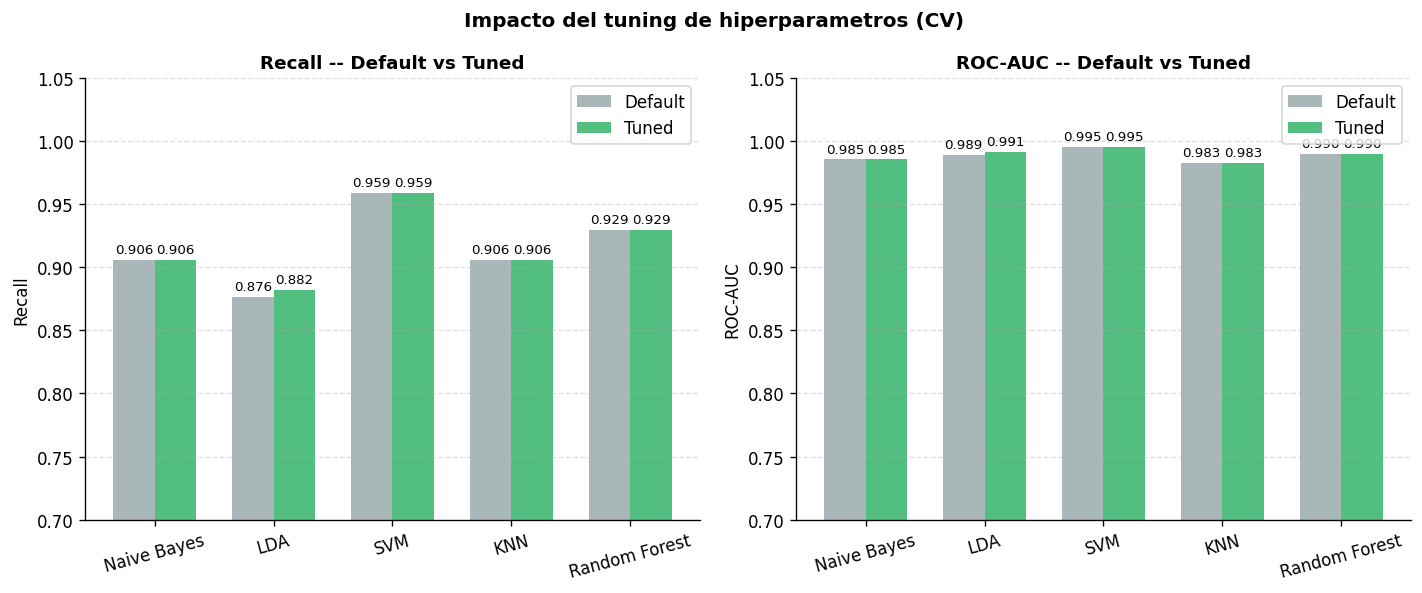

In [24]:
from sklearn.base import clone

ba_data = {}
for name in MODELS_TO_RUN:
    # Default
    model_def = clone(MODEL_REGISTRY[name])
    if name == "lda":
        model_def.set_params(solver="svd", shrinkage=None)
    pipe_def = make_pipeline(model_def)
    res_def = cross_validate(pipe_def, X_train, y_train, cv=cv,
                             scoring={"recall": "recall", "roc_auc": "roc_auc"},
                             n_jobs=-1)

    # Tuned
    model_tun = clone(MODEL_REGISTRY[name])
    if name == "lda":
        model_tun.set_params(solver="lsqr")
    pipe_tun = make_pipeline(model_tun)
    if name in BEST_PARAMS:
        pipe_tun.set_params(**BEST_PARAMS[name])
    res_tun = cross_validate(pipe_tun, X_train, y_train, cv=cv,
                             scoring={"recall": "recall", "roc_auc": "roc_auc"},
                             n_jobs=-1)

    ba_data[name] = {
        "recall_def": res_def["test_recall"].mean(),
        "recall_tun": res_tun["test_recall"].mean(),
        "roc_auc_def": res_def["test_roc_auc"].mean(),
        "roc_auc_tun": res_tun["test_roc_auc"].mean(),
    }

# Print table
print(f"\n{'Modelo':15s} | {'Recall Default':>14s} {'Recall Tuned':>13s} {'Delta':>8s} | "
      f"{'AUC Default':>12s} {'AUC Tuned':>10s} {'Delta':>8s}")
print("-" * 95)
for name in MODELS_TO_RUN:
    d = ba_data[name]
    dr = d["recall_tun"] - d["recall_def"]
    da = d["roc_auc_tun"] - d["roc_auc_def"]
    print(f"{MODEL_LABELS[name]:15s} | {d['recall_def']:14.4f} {d['recall_tun']:13.4f} {dr:+8.4f} | "
          f"{d['roc_auc_def']:12.4f} {d['roc_auc_tun']:10.4f} {da:+8.4f}")

# Bar chart: default vs tuned
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(MODELS_TO_RUN))
width = 0.35

for ax, (metric, label) in zip(axes, [("recall", "Recall"), ("roc_auc", "ROC-AUC")]):
    def_vals = [ba_data[n][f"{metric}_def"] for n in MODELS_TO_RUN]
    tun_vals = [ba_data[n][f"{metric}_tun"] for n in MODELS_TO_RUN]
    labels = [MODEL_LABELS[n] for n in MODELS_TO_RUN]

    bars1 = ax.bar(x - width/2, def_vals, width, label="Default", color="#95A5A6", alpha=0.8)
    bars2 = ax.bar(x + width/2, tun_vals, width, label="Tuned", color="#27AE60", alpha=0.8)

    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} -- Default vs Tuned", fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.legend()
    ax.set_ylim(0.7, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bar, val in zip(bars1, def_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    for bar, val in zip(bars2, tun_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Impacto del tuning de hiperparametros (CV)", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "before_after_tuning.png"), bbox_inches="tight")
plt.show()
plt.close(fig)

## Modelo final -- evaluacion en test

Elegir el mejor modelo (basado en recall CV), reentrenarlo sobre todo el train set
y evaluar **una sola vez** en test.

In [25]:
from sklearn.base import clone
# Seleccion automatica por recall CV tuned
BEST_MODEL_NAME = max(cv_results_tuned, key=lambda m: cv_results_tuned[m]["recall_mean"])
print(f"Mejor modelo por recall CV: {MODEL_LABELS[BEST_MODEL_NAME]}")

# Reentrenar sobre todo el train
_final_model = clone(MODEL_REGISTRY[BEST_MODEL_NAME])
if BEST_MODEL_NAME == "lda":
    _final_model.set_params(solver="lsqr")
best_pipe = make_pipeline(_final_model)
if BEST_MODEL_NAME in BEST_PARAMS:
    best_pipe.set_params(**BEST_PARAMS[BEST_MODEL_NAME])
best_pipe.fit(X_train, y_train)

# Evaluacion en test
y_pred      = best_pipe.predict(X_test)
y_prob      = best_pipe.predict_proba(X_test)[:, 1]

test_recall  = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)
test_f1      = f1_score(y_test, y_pred)
test_acc     = accuracy_score(y_test, y_pred)

print(f"\nTest set -- {MODEL_LABELS[BEST_MODEL_NAME]}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")
print(f"  F1:        {test_f1:.4f}")
print(f"  Accuracy:  {test_acc:.4f}")

Mejor modelo por recall CV: SVM

Test set -- SVM
  Recall:    0.9286
  ROC-AUC:   0.9954
  F1:        0.9398
  Accuracy:  0.9561


### Confusion matrix + ROC del modelo final

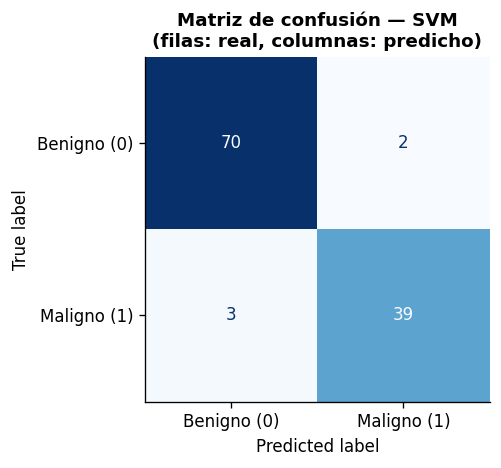

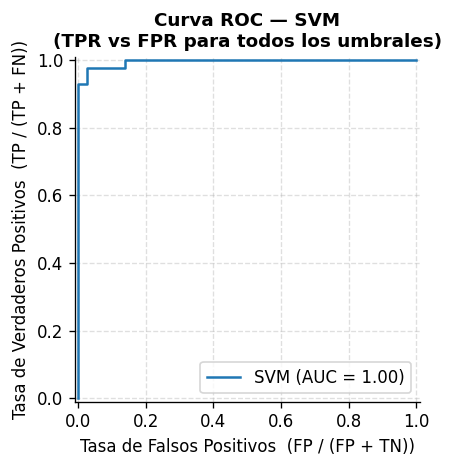

In [26]:
out_dir = ensure_output_dir(BEST_MODEL_NAME)
plot_confusion_matrix(best_pipe, X_test, y_test,
                      MODEL_LABELS[BEST_MODEL_NAME],
                      save_path=os.path.join(out_dir, "confusion_matrix_test.png"))
plot_roc_curve(best_pipe, X_test, y_test,
               MODEL_LABELS[BEST_MODEL_NAME],
               save_path=os.path.join(out_dir, "roc_curve_test.png"))